In [1]:
import sys
import os
import time
import numpy as np
import pandas as pd
import torch
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines
import pandas as pd


device = "cuda" if torch.cuda.is_available() else "cpu"

# where my preprocessed NSD files live
nsd_path = '/lab_data/hendersonlab/datasets/nsd_preproc'
data_folder = os.path.join(nsd_path, 'data')
labels_folder = os.path.join(nsd_path, 'labels')
stim_folder = os.path.join(nsd_path, 'stimuli')
rois_folder = os.path.join(nsd_path, 'rois')

# where the model fits are saved and loaded from:
save_fits_folder = '/lab_data/hendersonlab/projects/eccbias/model_fits/'

sys.path.append('/lab_data/hendersonlab/code/utils/')
import stats_utils

In [2]:
fig_path = '/lab_data/hendersonlab/projects/eccbias/figures/'
if not os.path.exists(fig_path):
    os.makedirs(fig_path)

In [3]:
subjects = np.arange(1, 9)
# subjects = [1]

model_names = ['resnet18-Baseline_concat', \
               'resnet18-FoveaGaze_concat', \
               'resnet18-PeriphNonTTM_concat', \
               'resnet18-PeriphTTM_concat', \
               'resnet18-pretrained-simclr_concat', \
               'resnet18-simclr-imgnet100_concat', \
               'resnet18-simclr-imgnet1k_concat', 
               'resnet18-pretrained-imgnet_concat']

model_names_short = ['Baseline',\
                     'Fovea-Gaze',\
                     'Periph',\
                     'Periph-NF',\
                     'STL10',\
                     'ImageNet-100',\
                     'ImageNet-1K (SSL)', \
                     'ImageNet-1K (supervised)']

fits = dict([])

for name in model_names:

    fits[name] = dict([])

    for si, ss in enumerate(subjects):

        name_short = name.split('_block')[0]
        name_short = name_short.split('_concat')[0]
        save_folder = os.path.join(save_fits_folder, name_short)
        filename = os.path.join(save_folder, 'NSD_S%d_%s.npy'%(ss, name))
        print(filename)
        readable_time = datetime.fromtimestamp(os.path.getmtime(filename)).strftime('%B %d, %Y at %I:%M %p')
        print(f"Last modified: {readable_time}")
        out = np.load(filename, allow_pickle=True).item()
        
        voxel_mask = out['voxel_mask']
    
        fits[name][ss] = out

/lab_data/hendersonlab/projects/eccbias/model_fits/resnet18-Baseline/NSD_S1_resnet18-Baseline_concat.npy
Last modified: February 08, 2026 at 09:27 PM
/lab_data/hendersonlab/projects/eccbias/model_fits/resnet18-Baseline/NSD_S2_resnet18-Baseline_concat.npy
Last modified: February 08, 2026 at 10:55 PM
/lab_data/hendersonlab/projects/eccbias/model_fits/resnet18-Baseline/NSD_S3_resnet18-Baseline_concat.npy
Last modified: February 08, 2026 at 10:56 PM
/lab_data/hendersonlab/projects/eccbias/model_fits/resnet18-Baseline/NSD_S4_resnet18-Baseline_concat.npy
Last modified: February 08, 2026 at 10:57 PM
/lab_data/hendersonlab/projects/eccbias/model_fits/resnet18-Baseline/NSD_S5_resnet18-Baseline_concat.npy
Last modified: February 08, 2026 at 10:58 PM
/lab_data/hendersonlab/projects/eccbias/model_fits/resnet18-Baseline/NSD_S6_resnet18-Baseline_concat.npy
Last modified: February 08, 2026 at 10:59 PM
/lab_data/hendersonlab/projects/eccbias/model_fits/resnet18-Baseline/NSD_S7_resnet18-Baseline_concat

In [4]:
vox_floc_tstats = dict([])
for subject in subjects:
    # load the pRF estimates (see "proc_rois.py")
    fn = os.path.join(rois_folder, 'S%d_floc_tstats.npy'%subject)
    tstats = np.load(fn, allow_pickle=True).item()
    vox_floc_tstats[subject] = tstats

In [6]:
sys.path.append('/lab_data/hendersonlab/code/feature_extraction/')
import prf_utils

# where my preprocessed NSD files live
# this is where we have the pre-computed pRF estimates for each voxel, for each subject
nsd_path = '/lab_data/hendersonlab/datasets/nsd_preproc'
rois_folder = os.path.join(nsd_path, 'rois')

vox_prfs = dict([])

for ss in subjects:

    vox_prfs[ss] = dict([])
    
    # load the pRF estimates (see "proc_rois.py")
    fn = os.path.join(rois_folder, 'S%d_prf_params.npy'%ss)
    prf_info = np.load(fn, allow_pickle=True).item()
    
    # units of degrees
    a = prf_info['angle']
    e = prf_info['eccen']
    s = prf_info['size']
    
    # Converting them into [x, y] coordinates, from polar
    # The units here are degrees visual angle
    x_mapping, y_mapping = prf_utils.pol_to_cart(a,e)
    
    # this step is taking out any extreme values, way outside the image range.
    # 7 is the max extent of the pRF grid in x,y (0.8333 * 8.4)
    x_mapping = np.minimum(np.maximum(x_mapping, -7), 7)
    y_mapping = np.minimum(np.maximum(y_mapping, -7), 7)
    
    e_mapping = np.minimum(e, 7)
    # S = pRF size, sigma of the Gaussian function. Degrees visual angle.
    # again taking out any huge values here. 8.4 is max degrees of pRF grid.
    s_mapping = np.minimum(s, 8.4)

    vox_prfs[ss]['ecc'] = e_mapping
    vox_prfs[ss]['size'] = s_mapping
    vox_prfs[ss]['polarang'] = a
    vox_prfs[ss]['x_pos'] = x_mapping
    vox_prfs[ss]['y_pos'] = y_mapping
    


In [7]:
# Load info about rois and voxels in the data
rinfo_allsubs = dict([])

for si, ss in enumerate(subjects):
        
    fn = os.path.join(rois_folder, 'S%d_voxel_roi_info.npy'%ss)
    rinfo = np.load(fn, allow_pickle=True).item()
    rinfo_allsubs[ss] = rinfo

def get_roi_vox(ss, roi_name = 'FFA-2', floc_thresh=None):

    rinfo = rinfo_allsubs[ss]
    voxel_mask = rinfo['voxel_mask']
    
    all_ret_names = (list(rinfo['ret_prf_roi_names'].keys()) + ['V1','V2','V3'])
    all_place_names = (list(rinfo['floc_place_roi_names'].keys()))
    all_face_names = (list(rinfo['floc_face_roi_names'].keys()) + ['FFA'])
    all_body_names = (list(rinfo['floc_body_roi_names'].keys()) + ['FBA'])
    all_word_names = (list(rinfo['floc_word_roi_names'].keys()) + ['VWFA'])

    if roi_name in all_ret_names:
        if np.isin(roi_name, ['V1','V2','V3']):
            dorsal_name = '%sd'%roi_name
            ventral_name = '%sv'%roi_name
            ind_num = [rinfo['ret_prf_roi_names'][dorsal_name], rinfo['ret_prf_roi_names'][ventral_name]]
        else:
            ind_num = [rinfo['ret_prf_roi_names'][roi_name]]
            
        roi_inds = np.isin(rinfo['roi_labels_retino'][voxel_mask], ind_num)

    elif roi_name in all_face_names:
        if np.isin(roi_name, ['FFA']):
            name1 = '%s-1'%roi_name
            name2 = '%s-2'%roi_name
            ind_num = [rinfo['floc_face_roi_names'][name1], rinfo['floc_face_roi_names'][name2]]
        else:
            ind_num = [rinfo['floc_face_roi_names'][roi_name]]
            
        roi_inds = np.isin(rinfo['roi_labels_face'][voxel_mask], ind_num)

        if floc_thresh is not None:
            t = vox_floc_tstats[ss]['faces']
            roi_inds = roi_inds & (t>floc_thresh)
    
    elif roi_name in all_place_names:
        ind_num = rinfo['floc_place_roi_names'][roi_name]
        roi_inds = rinfo['roi_labels_place'][voxel_mask]==ind_num

        if floc_thresh is not None:
            t = vox_floc_tstats[ss]['places']
            roi_inds = roi_inds & (t>floc_thresh)
    
    elif roi_name in all_body_names:
        if np.isin(roi_name, ['FBA']):
            name1 = '%s-1'%roi_name
            name2 = '%s-2'%roi_name
            ind_num = [rinfo['floc_body_roi_names'][name1], rinfo['floc_body_roi_names'][name2]]
        else:
            ind_num = [rinfo['floc_body_roi_names'][roi_name]]
        
        roi_inds = np.isin(rinfo['roi_labels_body'][voxel_mask], ind_num)

        if floc_thresh is not None:
            t = vox_floc_tstats[ss]['bodies']
            roi_inds = roi_inds & (t>floc_thresh)

    
    elif roi_name in all_word_names:
        if np.isin(roi_name, ['VWFA']):
            name1 = '%s-1'%roi_name
            name2 = '%s-2'%roi_name
            ind_num = [rinfo['floc_word_roi_names'][name1], rinfo['floc_word_roi_names'][name2]]
        else:
            ind_num = [rinfo['floc_word_roi_names'][roi_name]]
            
        roi_inds = np.isin(rinfo['roi_labels_word'][voxel_mask], ind_num)

        if floc_thresh is not None:
            t = vox_floc_tstats[ss]['characters']
            roi_inds = roi_inds & (t>floc_thresh)

    elif roi_name=='IPS':
        # concatenate IPS0-5 here
        all_kastner_names = rinfo['kastner_atlas_roi_names'].keys()
        ips_subregions = [k for k in all_kastner_names if 'IPS' in k]
        inds_num = [rinfo['kastner_atlas_roi_names'][k] for k in ips_subregions]
        roi_inds = np.isin(rinfo['roi_labels_kastner'][voxel_mask], inds_num)

    return roi_inds


In [8]:
roi_names = ['V1','V2','V3','hV4',\
             'OFA','FFA','OWFA','VWFA', \
             'OPA','PPA','RSC']

n_rois = len(roi_names)
n_subjects = len(subjects)
n_models = len(model_names)

avg_vals = np.zeros((n_subjects, n_rois, n_models))

avg_nc =  np.zeros((n_subjects, n_rois))

for si, ss in enumerate(subjects):
        
    for mi, name in enumerate(model_names):
    
        r2 = fits[name][ss]['r2']
        nc = fits[name][ss]['voxel_nc']/100
    
        above_thresh = nc > 0.10

        for ri, roi_name in enumerate(roi_names):
    
            roi_inds = get_roi_vox(ss, roi_name = roi_name, floc_thresh = 2)
            
            vals = r2[roi_inds & above_thresh]

            avg_vals[si, ri, mi] = np.mean(vals)

            avg_nc[si, ri] = np.mean(nc[roi_inds & above_thresh])

    

In [9]:
# Plotting parameters and color definitions
project_root = '/lab_data/hendersonlab/projects/eccbias/'

figpath = os.path.join(project_root, 'figures')
if not os.path.exists(figpath):
    os.makedirs(figpath)
plt.rcParams['pdf.fonttype']=42

# exp_colors = cm.viridis(np.linspace(0, 1, 5))[0:4,:]
exp_colors = cm.tab10(np.linspace(0, 1, 10))[0:4,:]

# comp_color = cm.gray(np.linspace(0, 1, 6))[1:5,:]
comp_color = cm.gray(np.linspace(0, 1, 5))[1:4,:]

cond_colors = np.concatenate([exp_colors, comp_color], axis=0)

### Plot all the conditions:

In [66]:
np.max(avg_vals)

np.float64(0.3457414935757033)

(0.0, 0.35)

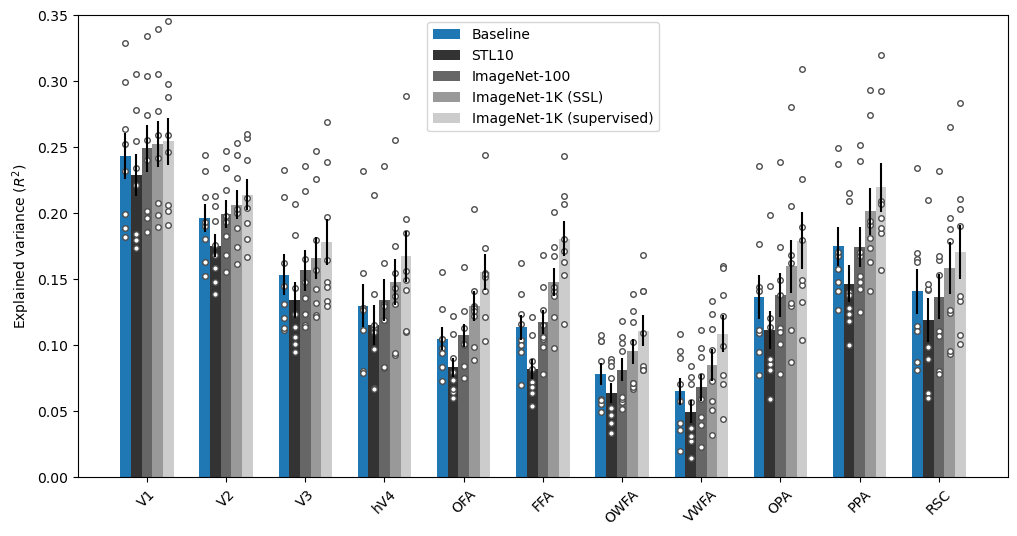

In [63]:
models_plot = [0,4,5,6,7]

jitters = np.linspace(-0.27, 0.27, len(models_plot))
width = (jitters[1]-jitters[0])*1.0

# cond_colors = cm.viridis(np.linspace(0, 1, 5))

fig, axes = plt.subplots(1, 1, figsize=(12, 6))
axes = [axes]
pi = 0

lh = []
for mi, mm in enumerate(models_plot):

    v = avg_vals[:,:,mm]
    
    m = np.mean(v, axis=0)
    s = np.std(v, axis=0) / np.sqrt(n_subjects)

    h = axes[pi].bar(np.arange(n_rois)+jitters[mi], m, width = width, color=cond_colors[mm,:])
    lh += [h]
    
    axes[pi].errorbar(np.arange(n_rois)+jitters[mi], m, yerr=s, color='k', linestyle='none', zorder=10)

for ri in range(n_rois):
    # axes[pi].plot(ri+jitters, avg_vals[:,ri,np.array(models_plot)].T, '.', \
    #               color=[0.8, 0.8, 0.8],markeredgecolor=[0.8, 0.8, 0.8], zorder=8)
    # axes[pi].plot(ri+jitters, avg_vals[:,ri,np.array(models_plot)].T, '.', \
    #               color=[0.6, 0.6, 0.6],markeredgecolor=[0.6, 0.6, 0.6], zorder=8)
    axes[pi].plot(ri+jitters, avg_vals[:,ri,np.array(models_plot)].T, 'o', \
                  color='w',markeredgecolor=[0.3, 0.3, 0.3], markersize=4, zorder=8)

axes[pi].legend(lh, np.array(model_names_short)[np.array(models_plot)])

axes[pi].set_ylabel('Explained variance ($R^2$)')
axes[pi].set_xticks(np.arange(n_rois), roi_names, rotation=45);
axes[pi].set_ylim([0, 0.35])

# fn2save = os.path.join(figpath, 'R2_allbaselines_bars.pdf')
# print(fn2save)

# plt.savefig(fn2save)

/lab_data/hendersonlab/projects/eccbias/figures/R2_allbaselines_bars.pdf


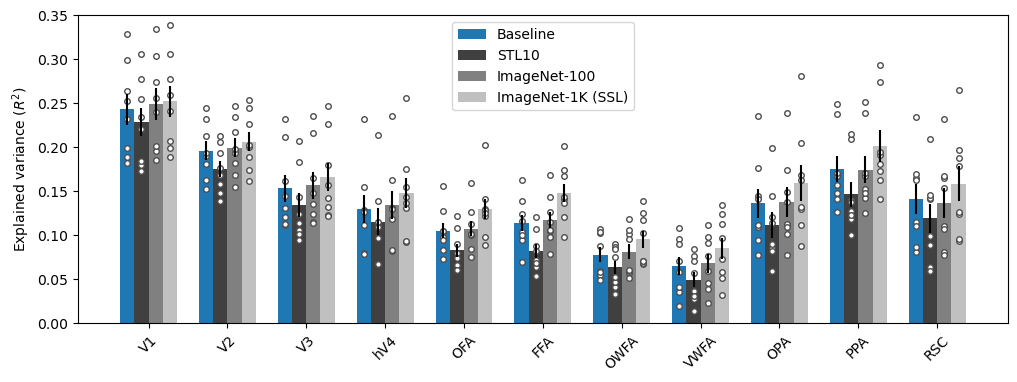

In [73]:
models_plot = [0,4,5,6]

jitters = np.linspace(-0.27, 0.27, len(models_plot))
width = (jitters[1]-jitters[0])*1.0

# cond_colors = cm.viridis(np.linspace(0, 1, 5))

fig, axes = plt.subplots(1, 1, figsize=(12, 4))
axes = [axes]
pi = 0

lh = []
for mi, mm in enumerate(models_plot):

    v = avg_vals[:,:,mm]
    
    m = np.mean(v, axis=0)
    s = np.std(v, axis=0) / np.sqrt(n_subjects)

    h = axes[pi].bar(np.arange(n_rois)+jitters[mi], m, width = width, color=cond_colors[mm,:])
    lh += [h]
    
    axes[pi].errorbar(np.arange(n_rois)+jitters[mi], m, yerr=s, color='k', linestyle='none', zorder=10)

for ri in range(n_rois):
    # axes[pi].plot(ri+jitters, avg_vals[:,ri,np.array(models_plot)].T, '.', \
    #               color=[0.8, 0.8, 0.8],markeredgecolor=[0.8, 0.8, 0.8], zorder=8)
    # axes[pi].plot(ri+jitters, avg_vals[:,ri,np.array(models_plot)].T, '.', \
    #               color=[0.6, 0.6, 0.6],markeredgecolor=[0.6, 0.6, 0.6], zorder=8)
    axes[pi].plot(ri+jitters, avg_vals[:,ri,np.array(models_plot)].T, 'o', \
                  color='w',markeredgecolor=[0.3, 0.3, 0.3], markersize=4, zorder=8)

axes[pi].legend(lh, np.array(model_names_short)[np.array(models_plot)])

axes[pi].set_ylabel('Explained variance ($R^2$)')
axes[pi].set_xticks(np.arange(n_rois), roi_names, rotation=45);
axes[pi].set_ylim([0, 0.35])

fn2save = os.path.join(figpath, 'R2_allbaselines_bars.pdf')
print(fn2save)

plt.savefig(fn2save)

In [68]:
ri+jitters[mi]

np.float64(10.27)

In [69]:
avg_vals.shape

(8, 11, 8)

In [70]:
avg_vals[:,ri,mm].shape

(8,)

/lab_data/hendersonlab/projects/eccbias/figures/R2_vedb_models_bars.pdf


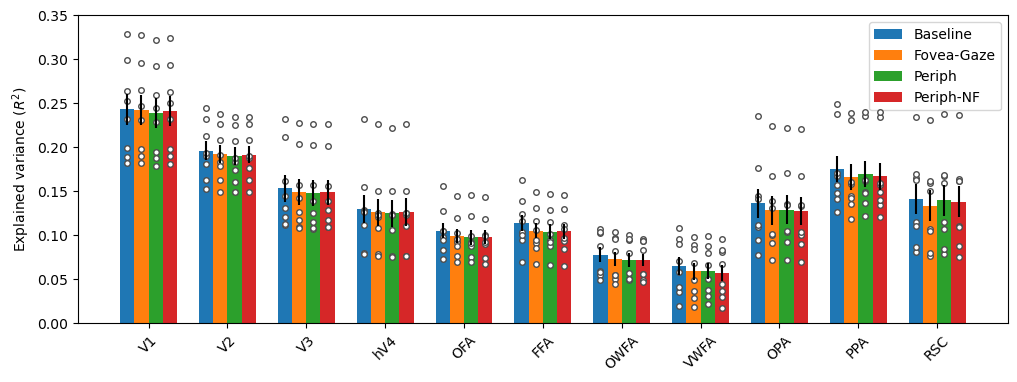

In [72]:
plt.rcParams['pdf.fonttype']=42

models_plot = [0,1,2,3]

jitters = np.linspace(-0.27, 0.27, len(models_plot))
width = (jitters[1]-jitters[0])*1.0

# cond_colors = cm.viridis(np.linspace(0, 1, 5))

fig, axes = plt.subplots(1, 1, figsize=(12, 4))
axes = [axes]
pi = 0

lh = []
for mi, mm in enumerate(models_plot):

    v = avg_vals[:,:,mm]
    
    m = np.mean(v, axis=0)
    s = np.std(v, axis=0) / np.sqrt(n_subjects)

    h = axes[pi].bar(np.arange(n_rois)+jitters[mi], m, width = width, color=cond_colors[mm,:])
    lh += [h]
    
    axes[pi].errorbar(np.arange(n_rois)+jitters[mi], m, yerr=s, color='k', linestyle='none', zorder=10)

for ri in range(n_rois):
    # axes[pi].plot(ri+jitters, avg_vals[:,ri,np.array(models_plot)].T, '.', \
    #               color=[0.6, 0.6, 0.6],markeredgecolor=[0.6, 0.6, 0.6], zorder=8)

    axes[pi].plot(ri+jitters, avg_vals[:,ri,np.array(models_plot)].T, 'o', \
                  color='w',markeredgecolor=[0.3, 0.3, 0.3], markersize=4, zorder=8)

axes[pi].legend(lh, np.array(model_names_short)[np.array(models_plot)])

axes[pi].set_ylabel('Explained variance ($R^2$)')
axes[pi].set_xticks(np.arange(n_rois), roi_names, rotation=45);
axes[pi].set_ylim([0, 0.35])

fn2save = os.path.join(figpath, 'R2_vedb_models_bars.pdf')
print(fn2save)

plt.savefig(fn2save)

### Put numbers into a table:

In [10]:
models_plot = [0,1,2,3,4,5,6]

m = np.mean(avg_vals[:,:,models_plot], axis=0)

pd.DataFrame(m.round(2), \
             index=roi_names, \
             columns=['R2: %s'%ss for ss in np.array(model_names_short)[np.array(models_plot)]])

,R2: Baseline,R2: Fovea-Gaze,R2: Periph,R2: Periph-NF,R2: STL10,R2: ImageNet-100,R2: ImageNet-1K (SSL)
V1,0.24,0.24,0.24,0.24,0.23,0.25,0.25
V2,0.20,0.19,0.19,0.19,0.18,0.20,0.21
V3,0.15,0.15,0.15,0.15,0.13,0.16,0.17
hV4,0.13,0.13,0.13,0.13,0.12,0.13,0.15
OFA,0.11,0.10,0.10,0.10,0.08,0.11,0.13
FFA,0.11,0.11,0.10,0.10,0.08,0.12,0.15
OWFA,0.08,0.07,0.07,0.07,0.06,0.08,0.10
VWFA,0.07,0.06,0.06,0.06,0.05,0.07,0.09
OPA,0.14,0.13,0.13,0.13,0.11,0.14,0.16
PPA,0.18,0.17,0.17,0.17,0.15,0.17,0.20


In [12]:
mi1 = 0
mi2 = 6
print('%s vs %s'%(model_names_short[mi1], model_names_short[mi2]))
max_diff = np.argmax(m[:,mi2]-m[:,mi1])
print(roi_names[max_diff])

vals1 = avg_vals[:, max_diff, mi1]
vals2 = avg_vals[:, max_diff, mi2]

print('%.2f +/- %.2f'%(np.mean(vals1), np.std(vals1)/np.sqrt(n_subjects)))
print('%.2f +/- %.2f'%(np.mean(vals2), np.std(vals2)/np.sqrt(n_subjects)))

Baseline vs ImageNet-1K (SSL)
FFA
0.11 +/- 0.01
0.15 +/- 0.01


/lab_data/hendersonlab/projects/eccbias/figures/R2_allmodels_extrabaselines_bars.pdf


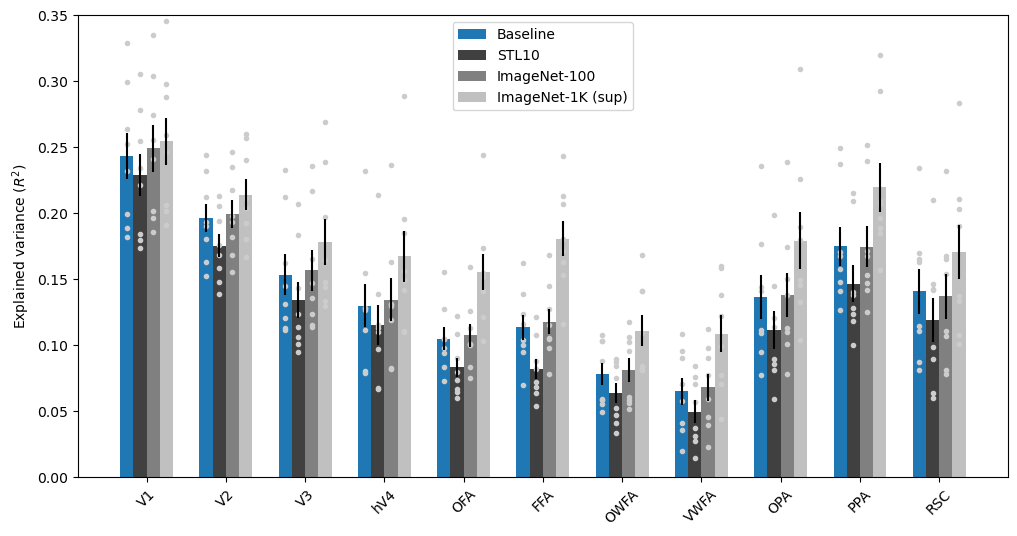

In [39]:
models_plot = [0,4,5,6]

jitters = np.linspace(-0.25, 0.25, len(models_plot))
width = (jitters[1]-jitters[0])*1.0

# cond_colors = cm.viridis(np.linspace(0, 1, 5))

fig, axes = plt.subplots(1, 1, figsize=(12, 6))
axes = [axes]
pi = 0

lh = []
for mi, mm in enumerate(models_plot):

    v = avg_vals[:,:,mm]
    
    m = np.mean(v, axis=0)
    s = np.std(v, axis=0) / np.sqrt(n_subjects)

    h = axes[pi].bar(np.arange(n_rois)+jitters[mi], m, width = width, color=cond_colors[mm,:])
    lh += [h]
    
    axes[pi].errorbar(np.arange(n_rois)+jitters[mi], m, yerr=s, color='k', linestyle='none', zorder=10)

for ri in range(n_rois):
    axes[pi].plot(ri+jitters, avg_vals[:,ri,np.array(models_plot)].T, '.', color=[0.8, 0.8, 0.8], zorder=8)

axes[pi].legend(lh, np.array(model_names_short)[np.array(models_plot)])

axes[pi].set_ylabel('Explained variance ($R^2$)')
axes[pi].set_xticks(np.arange(n_rois), roi_names, rotation=45);
axes[pi].set_ylim([0, 0.35])

fn2save = os.path.join(figpath, 'R2_allmodels_extrabaselines_bars.pdf')
print(fn2save)


/lab_data/hendersonlab/projects/eccbias/figures/R2_vc_NC_baseline_resnet18-Baseline_concat.pdf


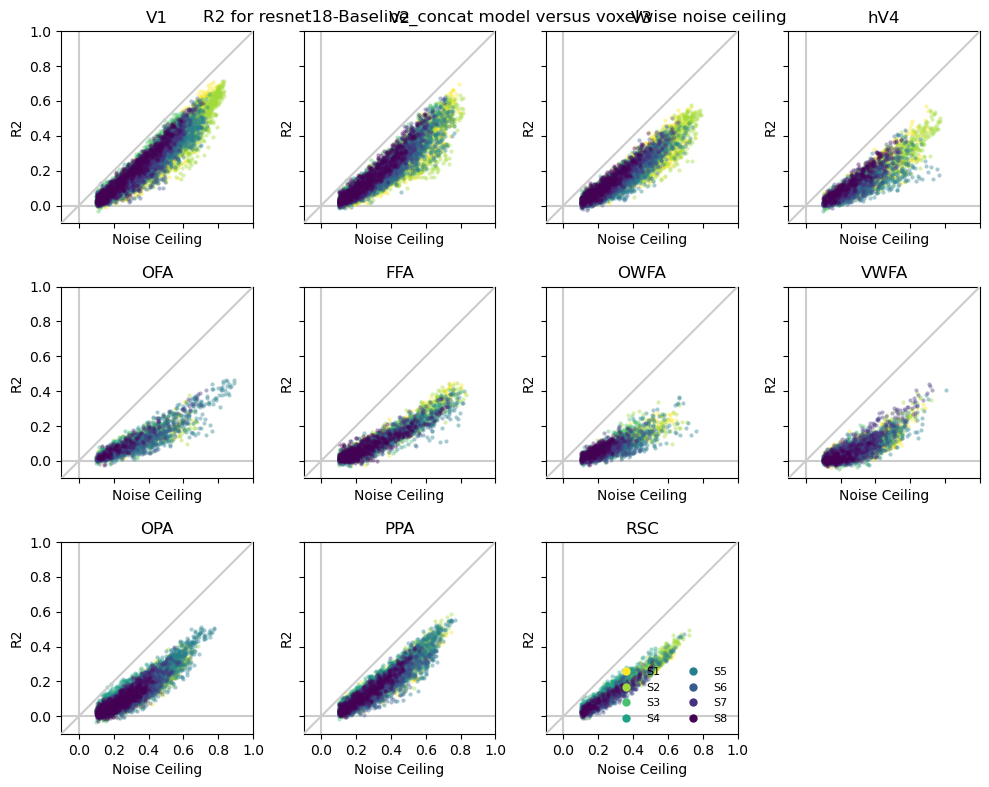

In [33]:
mi = 0 # baseline

subcolors = np.flipud(cm.viridis( np.linspace(0,1,n_subjects) ))


name = model_names[mi]


limits = [-0.1, 1.0]
ticks = [0, 0.2, 0.4, 0.6, 0.8, 1.0]

fig, axes = plt.subplots(3, 4, sharex = True, sharey = True, figsize=(10, 8))
axes = axes.flatten()

pi=-1

for ri, roi_name in enumerate(roi_names):

    pi = pi+1
    
    for si, ss in enumerate(subjects):
        
        r2 = fits[name][ss]['r2'] 

        nc = fits[name][ss]['voxel_nc'] / 100
        
        roi_inds = get_roi_vox(ss, roi_name = roi_name, floc_thresh = 2) 
    
        roi_inds = roi_inds & (nc>0.10)
    
        x = nc[roi_inds]
        y = r2[roi_inds]
        
        # axes[pi].plot(x, y, '.', alpha=0.4, markeredgecolor='none', rasterized=True)
        axes[pi].plot(x, y, '.', color=subcolors[si], alpha=0.4, markeredgecolor='none', rasterized=True)
        
    axes[pi].plot(limits, limits, color=[0.8, 0.8, 0.8], zorder=10)
    axes[pi].axvline(0,color=[0.8, 0.8, 0.8], zorder=-10)
    axes[pi].axhline(0,color=[0.8, 0.8, 0.8], zorder=-10)
    
    axes[pi].set_aspect('equal')

    axes[pi].set_title(roi_name)

    axes[pi].set_xlim(limits)
    axes[pi].set_ylim(limits)

    axes[pi].set_xticks(ticks)
    axes[pi].set_yticks(ticks)
    
    axes[pi].set_xlabel('Noise Ceiling')
    axes[pi].set_ylabel('R2')

# Create proxy handles for subjects
legend_handles = [
    mlines.Line2D([], [], marker='.', color=subcolors[si], markersize=8,
                  markeredgecolor='none', linestyle='none', label='S%d' % (si+1))
    for si in range(n_subjects)
]

# Place in the last subplot that's still visible (or any specific one)
axes[pi].legend(handles=legend_handles, loc='lower right', frameon=False,
                fontsize=8, ncol=2, markerscale=1.5)

for ax in axes[pi+1:]:
    ax.set_visible(False)
plt.tight_layout()
plt.suptitle('R2 for %s model versus voxelwise noise ceiling'%(name))

fn2save = os.path.join(figpath, 'R2_vc_NC_baseline_%s.pdf'%name)
print(fn2save)

plt.savefig(fn2save, dpi=500)

/lab_data/hendersonlab/projects/eccbias/figures/R2_vc_NC_baseline_resnet18-Baseline_concat.pdf


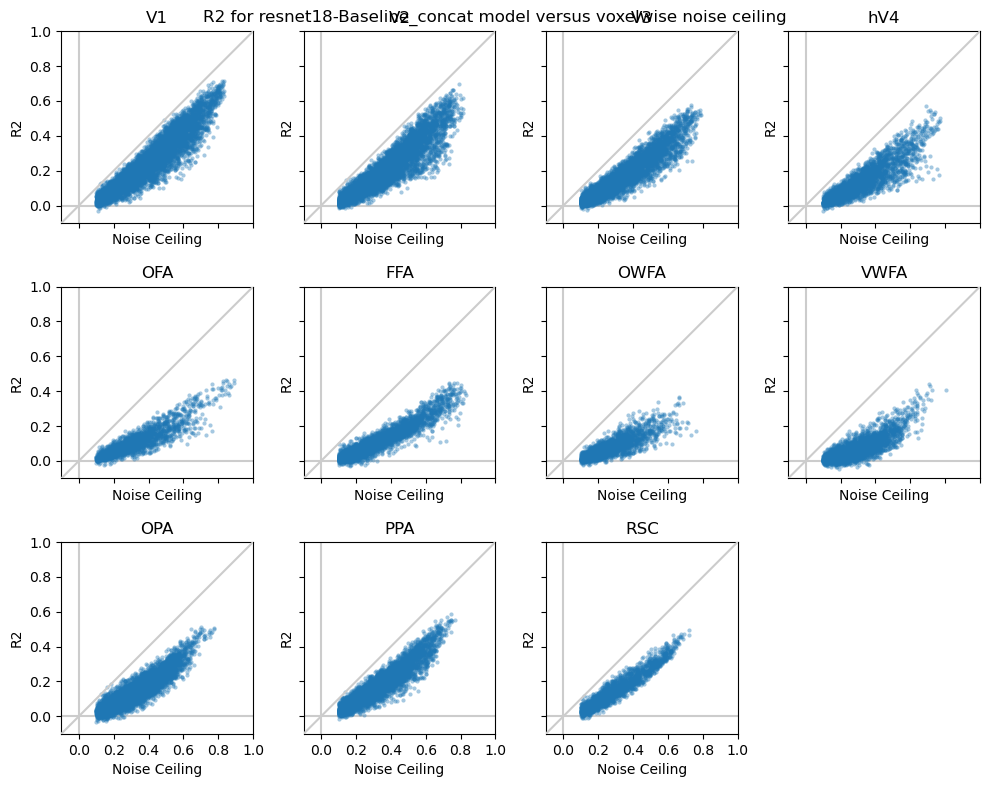

In [25]:
mi = 0 # baseline

name = model_names[mi]

r2 = np.concatenate([fits[name][ss]['r2'] for ss in subjects], axis=0)

nc = np.concatenate([fits[name][ss]['voxel_nc'] for ss in subjects], axis=0) / 100

limits = [-0.1, 1.0]
ticks = [0, 0.2, 0.4, 0.6, 0.8, 1.0]

fig, axes = plt.subplots(3, 4, sharex = True, sharey = True, figsize=(10, 8))
axes = axes.flatten()

pi=-1

for ri, roi_name in enumerate(roi_names):

    roi_inds = np.concatenate([get_roi_vox(ss, \
                                               roi_name = roi_name,\
                                               floc_thresh = 2) for ss in subjects], axis=0)

    roi_inds = roi_inds & (nc>0.10)

    x = nc[roi_inds]
    y = r2[roi_inds]
    
    pi = pi+1

    axes[pi].plot(x, y, '.', alpha=0.4, markeredgecolor='none', rasterized=True)
    
    axes[pi].plot(limits, limits, color=[0.8, 0.8, 0.8], zorder=10)
    axes[pi].axvline(0,color=[0.8, 0.8, 0.8], zorder=-10)
    axes[pi].axhline(0,color=[0.8, 0.8, 0.8], zorder=-10)
    
    axes[pi].set_aspect('equal')

    axes[pi].set_title(roi_name)

    axes[pi].set_xlim(limits)
    axes[pi].set_ylim(limits)

    axes[pi].set_xticks(ticks)
    axes[pi].set_yticks(ticks)
    
    axes[pi].set_xlabel('Noise Ceiling')
    axes[pi].set_ylabel('R2')

for ax in axes[pi+1:]:
    ax.set_visible(False)
plt.tight_layout()
plt.suptitle('R2 for %s model versus voxelwise noise ceiling'%(name))

fn2save = os.path.join(figpath, 'R2_vc_NC_baseline_%s.pdf'%name)
print(fn2save)

plt.savefig(fn2save, dpi=500)

Text(0.5, 0.98, 'R2 for resnet18-pretrained-imgnet_concat model versus voxelwise noise ceiling')

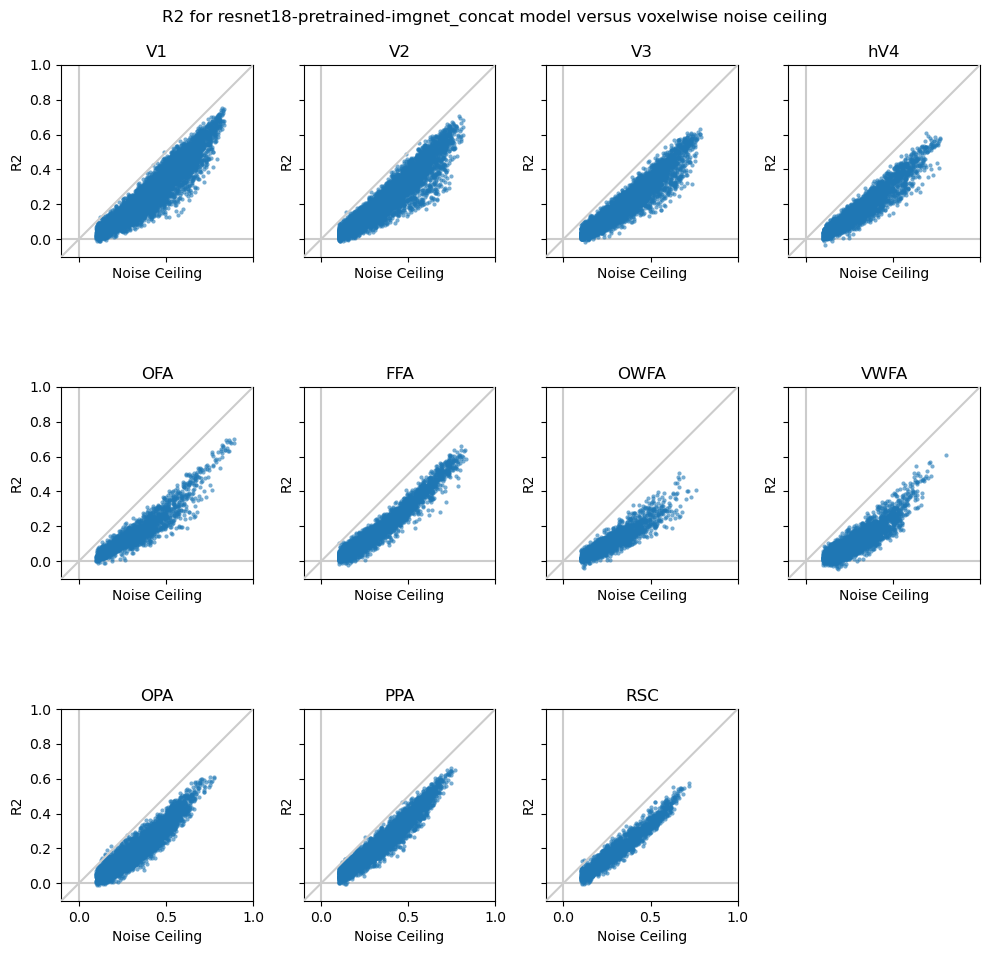

In [37]:
mi = 6 # baseline

name = model_names[mi]

r2 = np.concatenate([fits[name][ss]['r2'] for ss in subjects], axis=0)

nc = np.concatenate([fits[name][ss]['voxel_nc'] for ss in subjects], axis=0) / 100

limits = [-0.1, 1.0]
# ticks = [0, 0.4, 0.8]

fig, axes = plt.subplots(3, 4, sharex = True, sharey = True, figsize=(10, 10))
axes = axes.flatten()

pi=-1

for ri, roi_name in enumerate(roi_names):

    roi_inds = np.concatenate([get_roi_vox(ss, \
                                               roi_name = roi_name,\
                                               floc_thresh = 2) for ss in subjects], axis=0)

    roi_inds = roi_inds & (nc>0.10)

    x = nc[roi_inds]
    y = r2[roi_inds]
    
    pi = pi+1

    axes[pi].plot(x, y, '.', alpha=0.6, markeredgecolor='none')
    
    axes[pi].plot(limits, limits, color=[0.8, 0.8, 0.8], zorder=10)
    axes[pi].axvline(0,color=[0.8, 0.8, 0.8], zorder=-10)
    axes[pi].axhline(0,color=[0.8, 0.8, 0.8], zorder=-10)
    
    axes[pi].set_aspect('equal')

    axes[pi].set_title(roi_name)

    axes[pi].set_xlim(limits)
    axes[pi].set_ylim(limits)

    # axes[pi].set_xticks(ticks)
    # axes[pi].set_yticks(ticks)
    
    axes[pi].set_xlabel('Noise Ceiling')
    axes[pi].set_ylabel('R2')

for ax in axes[pi+1:]:
    ax.set_visible(False)
plt.tight_layout()
plt.suptitle('R2 for %s model versus voxelwise noise ceiling'%(name))